# CT4110 – Topic 4 Assignment
## Quantum Computing Software and Deutsch's Algorithm

In this exercise, you will use IBM Qiskit to construct, execute, and analyse quantum circuits.

Before starting, watch the **Introduction to Qiskit** tutorial in the Topic 4 Canvas module and run its notebook. The exercise uses the same workflow: create a `QuantumCircuit`, apply gates, draw the circuit, transpile it, run it with `AerSimulator`, and retrieve results. Statevector inspection and oracle construction are introduced below before they are required.

Keep every requested circuit diagram and numerical output visible in your submitted notebook.


In [ ]:
# ============================================================
# Course Setup – Run This Cell First
# ============================================================

# Try to import the course packages first.
# If they are already installed, no installation is performed.
# If an import fails, pip installs the pinned course versions.

try:
    import qiskit
    import qiskit_aer
    import matplotlib
    import pylatexenc
    import qiskit_nature
    import qiskit_algorithms
    import pyscf
    import scipy
    import numpy

    print("All course packages are already installed.")

except ImportError:
    import subprocess
    import sys

    print("A course package is missing. Installing the pinned versions...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "qiskit==2.5.2",
        "qiskit-aer==0.17.2",
        "matplotlib==3.11.1",
        "pylatexenc==2.10",
        "qiskit-nature==0.8.0",
        "qiskit-algorithms==0.4.0",
        "pyscf==2.14.0",
        "scipy==1.18.1",
        "numpy==2.5.2",
    ])

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

print("Qiskit imports successful!")


## Question 1 – Creating and Running a Qiskit Circuit

This question introduces the complete Qiskit workflow used throughout the exercise:

1. create a quantum circuit;
2. add quantum gates;
3. measure the qubit in the computational basis and store the result in a classical bit;
4. draw and check the circuit;
5. prepare the circuit for a simulator with `transpile`;
6. run the circuit for many shots;
7. retrieve counts and calculate experimental probabilities.

### Quantum and classical bits

Create a circuit containing one qubit and one classical bit. The qubit stores and processes quantum information. The classical bit stores the result produced when the qubit is measured.

Qiskit automatically initialises a new qubit in $|0\rangle$, so no gate is needed to prepare the initial state. Apply H to create

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}.
$$

The two amplitudes are both $1/\sqrt{2}$. Measurement probabilities are the squared magnitudes of the amplitudes, so

$$
P(|0\rangle)=\left|\frac{1}{\sqrt{2}}\right|^2=\frac{1}{2},
\qquad
P(|1\rangle)=\left|\frac{1}{\sqrt{2}}\right|^2=\frac{1}{2}.
$$

### Measurement and shots

A computational-basis measurement returns one classical outcome: 0 for $|0\rangle$ or 1 for $|1\rangle$. It does not display both amplitudes. To estimate the probabilities, repeat the complete circuit many times. Each repetition is called a **shot**.

Run at least 1,000 shots. The exact counts normally differ from run to run because measurement is probabilistic, but each experimental probability should be close to $1/2$. Compare experiment with theory by printing the absolute difference between each observed probability and 0.5.


In [ ]:
# Question 1 — Checkpoint 1: Build and draw the circuit
# Create qc with one qubit and one classical bit. Qiskit starts q0 in |0>.
# Apply H to q0, then measure q0 in the computational basis into classical bit 0.
#
# Syntax:
#
#     qc = QuantumCircuit(number_of_qubits, number_of_classical_bits)
#     qc.h(qubit_index)
#     qc.measure(qubit_index, classical_bit_index)
#
# Circuit and bit indices start at 0. Gate and measurement methods change qc in
# place, so do not assign their return values back to qc.

# YOUR CODE HERE

# REQUIRED DRAW CHECK
# Use qc.draw(output="mpl"). The diagram must show H followed by measurement,
# with q0 connected to classical bit 0.


In [ ]:
# Question 1 — Checkpoint 2: Transpile, run, and retrieve counts
# Create a local simulator, transpile qc for it, and run at least 1,000 shots.
# Retrieve the completed counts dictionary.
#
# Syntax:
#
#     simulator = AerSimulator(method="statevector")
#     transpiled_qc = transpile(qc, simulator)
#     shots = 1000
#     job = simulator.run(transpiled_qc, shots=shots)
#     result = job.result()
#     counts = result.get_counts()
#
# A shot is one complete prepare-run-measure experiment. The counts may look
# like {'0': 507, '1': 493}; exact values vary from run to run.

# YOUR CODE HERE

# REQUIRED NUMERICAL CHECK
# Print counts and sum(counts.values()). The total must equal shots.


In [ ]:
# Question 1 — Checkpoint 3: Compare experiment with theory
# Extract the two counts safely and divide each by shots.
#
# Syntax:
#
#     count_0 = counts.get('0', 0)
#     experimental_p0 = count_0 / shots
#
# Repeat for |1>. The theoretical values are P(|0>)=0.5 and P(|1>)=0.5.
# For each outcome, calculate the absolute difference between the experimental
# probability and the theoretical probability:
#
#     difference = abs(experimental probability - theoretical probability)

# YOUR CODE HERE

# REQUIRED NUMERICAL CHECK
# Print P(|0>), P(|1>), and label each comparison as the "difference between"
# "experimental and theoretical probability". Also print the sum of the
# two experimental probabilities. The sum should be 1 and both differences small.


### Qiskit gate reference

Qiskit applies gates as methods on a circuit: `qc.x(0)` flips a qubit, `qc.y(0)` applies a bit flip with a phase, `qc.z(0)` changes the phase of the $|1\rangle$ component, `qc.h(0)` creates or recombines superposition, and `qc.cx(control, target)` flips the target only when the control is $|1\rangle$. See IBM's [Qiskit standard-gate reference](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library) for the complete list and usage details.


## Question 2 – Bell State and Statevector Inspection

This question extends the Qiskit workflow from one qubit to two qubits. You will first construct and inspect the circuit while it is unmeasured. After saving the statevector results, you will add measurements directly to the same circuit and run it with shots.

### Build the Bell state

Qiskit initialises two new qubits in $|00\rangle$. Apply H to qubit 0, then apply CX with qubit 0 as the control and qubit 1 as the target:

$$
|00\rangle
\longrightarrow
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\longrightarrow
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
$$

The final state is the Bell state

$$
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
$$

The two qubits are correlated: measuring one as 0 means the other is also 0, and measuring one as 1 means the other is also 1.

### What a statevector represents

Before measurement, an ideal $n$-qubit state is represented by $2^n$ complex amplitudes. A two-qubit statevector therefore contains four entries:

Qiskit returns the entries in this order:

- index 0: basis state $|00\rangle$, amplitude $1/\sqrt{2}$, probability $1/2$;
- index 1: basis state $|01\rangle$, amplitude $0$, probability $0$;
- index 2: basis state $|10\rangle$, amplitude $0$, probability $0$;
- index 3: basis state $|11\rangle$, amplitude $1/\sqrt{2}$, probability $1/2$.

In Qiskit's statevector labels, the rightmost bit corresponds to qubit 0. This ordering matters when interpreting states that are not symmetric.

An amplitude is not itself a probability. For an amplitude $a+bi$, the corresponding probability is its squared magnitude:

$$
|a+bi|^2=a^2+b^2.
$$

Qiskit's `Statevector` class performs this ideal mathematical simulation without shots and without randomly selecting a measurement result.

### Inspect a circuit with `Statevector`

For an unmeasured circuit called `bell_qc`, use:

```python
state = Statevector(bell_qc)
amplitudes = state.data
probabilities = state.probabilities()

print(amplitudes)
print(probabilities)
print(sum(probabilities))
```

- `state.data` contains the complex amplitudes.
- `state.probabilities()` contains the probability of every computational-basis state.
- The probabilities should sum to 1 for a valid normalised state.

For this Bell state, the expected amplitude vector is

$$
\begin{bmatrix}
1/\sqrt{2} & 0 & 0 & 1/\sqrt{2}
\end{bmatrix},
$$

and the expected probability vector is

$$
\begin{bmatrix}
1/2 & 0 & 0 & 1/2
\end{bmatrix}.
$$


In [ ]:
# Question 2 — Checkpoint 1: Build and draw the Bell-state circuit
# Create bell_qc with two qubits and no classical bits. Apply H to q0, then CX
# with q0 as control and q1 as target. Add a barrier after state preparation.
#
# A barrier visually marks the end of a logical stage and prevents transpiler
# operations from moving across it. It does not change, measure, or reset a state.

# YOUR CODE HERE

# REQUIRED DRAW CHECK
# Use bell_qc.draw(output="mpl"). Check that H is followed by CX and a barrier.


In [ ]:
# Question 2 — Checkpoint 2: Inspect the statevector
# Inspect bell_qc before adding measurements. Statevector is an exact ideal
# simulation; it does not use shots or select one random outcome.
#
# Syntax:
#
#     state = Statevector(bell_qc)
#     amplitudes = state.data
#     probabilities = state.probabilities()
#
# The four entries correspond to |00>, |01>, |10>, and |11>. Each probability
# is the squared magnitude of its complex amplitude. For the Bell state, entries
# 0 and 3 should have amplitudes near 0.7071 and probabilities near 0.5; entries
# 1 and 2 should be zero. The probabilities must sum to 1.

# YOUR CODE HERE

# REQUIRED NUMERICAL CHECK
# Print amplitudes, probabilities, and sum(probabilities). Compare numerically
# with expected probabilities [0.5, 0.0, 0.0, 0.5].


### Add measurement after inspection

`Statevector(bell_qc)` must be evaluated before measurements are added. Once `state`, `amplitudes`, and `probabilities` have been stored, add measurements directly to the same circuit:

```python
bell_qc.measure_all()
```

`measure_all()` adds a classical bit for each qubit and measures every qubit. From this point onward, use `bell_qc` for the shot-based simulator run; do not try to construct another statevector from it after measurement has been added.

Ideally, the measured counts contain `00` and `11` only, with each occurring about half the time. This compares the exact probabilities saved before measurement with probabilities estimated from repeated shots.


In [ ]:
# Question 2 — Checkpoint 3: Measure, run, and compare
# The statevector values were saved while bell_qc was unmeasured. Now add
# measurements directly to bell_qc, then transpile and run it for at least
# 1,000 shots using the Question 1 workflow.
#
# Syntax:
#
#     bell_qc.measure_all()
#     transpiled_bell_qc = transpile(bell_qc, simulator)
#     bell_counts = simulator.run(
#         transpiled_bell_qc, shots=shots
#     ).result().get_counts()
#
# Use bell_counts.get(bit_string, 0) / shots for '00', '01', '10', and '11'.
# Do not call Statevector(bell_qc) after measurement has been added.

# YOUR CODE HERE

# REQUIRED DRAW AND NUMERICAL CHECKS
# First display bell_qc.draw(output="mpl"). Then print counts, their total, and
# each experimental probability beside [0.5, 0.0, 0.0, 0.5].


## Question 3 – Deutsch's Algorithm: Oracle Construction and Classification

### Part A – Build a representative oracle

Deutsch's algorithm uses a reversible oracle

$$
U_f|x\rangle|y\rangle=|x\rangle|y\oplus f(x)\rangle.
$$

Use qubit 0 for input $x$ and qubit 1 for output $y$. When $y=0$, the final output is $f(x)$. In this exercise, use the supplied truth table and circuit drawing to construct the requested oracle.

To reduce repetition while preserving both cases, this question uses:

- a worked **constant** oracle, $f_1(x)=1$;
- a student-built **balanced** oracle, $f_3(x)=1-x$.

### The four possible one-bit oracles

| Function | $f(0)$ | $f(1)$ | Type | Qiskit oracle construction |
|---|---:|---:|---|---|
| $f_0(x)=0$ | 0 | 0 | Constant | Empty two-qubit circuit |
| $f_1(x)=1$ | 1 | 1 | Constant | X on output qubit q1 |
| $f_2(x)=x$ | 0 | 1 | Balanced | CX with q0 controlling q1 |
| $f_3(x)=1-x$ | 1 | 0 | Balanced | Apply X to input q0, apply CX with q0 controlling output q1, then apply X to q0 again to restore the input |

The table shows all four possibilities, but the graded construction uses only $f_3$. The supplied $f_1$ circuit is a worked example.

### Worked example: constant oracle $f_1(x)=1$

This function returns 1 for both inputs. The output qubit must therefore always flip. An X gate on qubit 1 implements

$$
|x\rangle|y\rangle\longmapsto|x\rangle|y\oplus1\rangle.
$$

The completed worked example would be a two-qubit circuit with an X gate on output qubit q1. Its circuit drawing should show q0 unchanged and q1 passing through X.

This example follows the same three steps you should use for the other case:

1. identify when the output qubit must flip;
2. translate that condition into Qiskit gates;
3. draw the circuit and compare it with the required truth table.

For $f_3(x)=1-x$, the output must flip when $x=0$, rather than when $x=1$. A standard controlled-X gate activates for control value 1. Think about how temporarily changing the control qubit can turn the original $x=0$ case into the active-control case. After the controlled operation, the input qubit must be restored to its original value because an oracle must preserve $x$.

Use this description and the truth table to determine the required gate sequence yourself.

The worked $f_1$ code is an example only. The graded task is to construct $f_3$ and then use it in Deutsch's algorithm.


In [ ]:
# Question 3 — Checkpoint 1: Build f3(x)=1-x (balanced)
# Create a two-qubit circuit called oracle_f3. Qubit q0 stores x and q1 stores y.
# The truth table is:
#
#     x=0  ->  f3(x)=1
#     x=1  ->  f3(x)=0
#
# Therefore, the output y must flip only when the original input x is 0.
# A standard CX activates when its control is 1, so you need an inverted-control
# idea. Temporarily change the control condition, perform the controlled output
# operation, and restore the input qubit afterward.
#
# Create the two-qubit oracle circuit yourself and decide which gates it needs. Your completed oracle must change y according
# to the truth table while leaving x exactly as it started.

# YOUR CODE HERE

# REQUIRED DRAW CHECK
# Display oracle_f3.draw(output="mpl"). The drawing must show two qubit wires
# and the complete gate sequence used to implement f3(x)=1-x.


### Part B – Use the oracles in Deutsch's algorithm

Deutsch's algorithm determines whether a one-bit function is constant or balanced using one oracle application. In this exercise, run the complete algorithm only with the student-built balanced oracle $f_3$. The worked $f_1$ oracle is included to explain the constant construction, but it is not used as an additional algorithm test.

The circuit uses an input qubit q0 and auxiliary qubit q1:

1. prepare $|0\rangle|1\rangle$;
2. apply H to both qubits to obtain $|+\rangle|-\rangle$;
3. append the selected oracle once;
4. apply H again only to q0;
5. measure q0 in the computational basis.

### Expected Deutsch circuit

Build one circuit using your `oracle_f3`. The expected Qiskit Matplotlib drawing is shown below:

The rendered reference appears in the output cell immediately below.

Use barriers between preparation, oracle, interference, and measurement so these stages are clear in the Matplotlib drawing. Only q0 is measured.

To place the two-qubit oracle inside the Deutsch circuit, convert the completed oracle circuit into a gate, give that gate the label `Uf3`, and append it to q0 and q1. The oracle's first wire must map to q0 and its second wire to q1.

Converting the oracle packages its operations as one labelled block. Placing that block on q0 and q1 preserves the oracle's input-wire and output-wire roles.

The auxiliary state $|-\rangle$ turns the oracle action into a relative phase on q0. The final H converts that phase information into a deterministic measurement:

- `0` means constant;
- `1` means balanced.


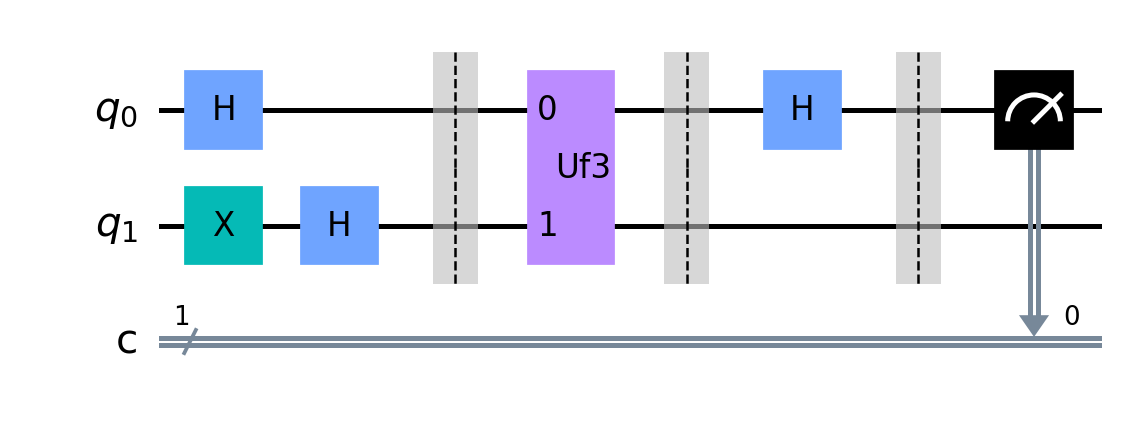

In [ ]:
# PROVIDED REFERENCE OUTPUT — no code is required in this cell.
# Expected Qiskit Matplotlib drawing of the Deutsch circuit.


In [ ]:
# Question 3 — Checkpoint 2: Build one Deutsch circuit using oracle_f3
# Create one circuit called deutsch_qc with two qubits and one classical bit.
# Build the preparation, oracle, interference, and measurement stages in order.
#
# 1. Preparation:
#    - apply X to auxiliary q1;
#    - apply H to q0 and q1;
#    - add a barrier.
# 2. Oracle:
#    - convert oracle_f3 to a gate;
#    - name the gate "Uf3";
#    - append it to qubits [0, 1];
#    - add a barrier.
# 3. Interference and measurement:
#    - apply H only to q0;
#    - add a barrier;
#    - measure q0 into classical bit 0.
#
# Convert the completed oracle into a gate, label it Uf3, and append it so its
# input wire maps to q0 and its output wire maps to q1.

# YOUR CODE HERE

# REQUIRED DRAW CHECK
# Use deutsch_qc.draw(output="mpl"). Compare it with the expected drawing above.
# It must contain one Uf3 block and measure only q0.


In [ ]:
# Question 3 — Checkpoint 3: Run the Deutsch circuit
# Use the same simulator workflow introduced in Question 1. Create the simulator,
# transpile deutsch_qc for it, run 1,000 shots, and retrieve the counts. Store the
# shot total and counts in clearly named variables for the final classification.

# YOUR CODE HERE

# REQUIRED NUMERICAL CHECK
# Print the counts and their total. The total must equal the number of shots, and
# the ideal counts should contain only one measured bit.


In [ ]:
# Question 3 — Written classification
# Based on the measurement outcome in deutsch_counts, decide whether the
# function is Constant or Balanced. Type your answer inside the brackets below.

# ANSWER: [ ]


## Question 4 – Advanced Task: Deutsch–Jozsa Algorithm and Query Complexity

Deutsch–Jozsa extends Deutsch's algorithm to a function with $n$ input bits:

$$
f:\{0,1\}^n\rightarrow\{0,1\}.
$$

The algorithm is given a **promise** that the function is one of two types:

- **constant:** every one of the $2^n$ inputs produces the same output;
- **balanced:** exactly half of the inputs produce 0 and the other half produce 1.

In this exercise, use $n=3$. There are therefore $2^3=8$ possible input strings. The supplied oracle is deliberately not labelled as constant or balanced; the circuit's measurement must determine its type.

### Part A – Create the registers

The circuit requires:

- $n=3$ input qubits;
- one auxiliary qubit;
- $n=3$ classical bits for the input-register measurements.

Qiskit starts all four qubits in $|0\rangle$. Apply X to auxiliary qubit $q_n$, which is qubit 3, to prepare the conceptual state

$$
|000\rangle|1\rangle.
$$

### Part B – Create the initial superposition

Apply H to every qubit. The input register becomes an equal superposition of all eight inputs:

$$
\frac{1}{\sqrt{8}}\sum_{x=0}^{7}|x\rangle,
$$

while the auxiliary qubit becomes $|-\rangle$. The complete state is

$$
\left(\frac{1}{\sqrt{8}}\sum_{x=0}^{7}|x\rangle\right)|-\rangle.
$$

### Part C – Apply the supplied oracle once

The oracle acts on all three input qubits and the auxiliary qubit. As in Deutsch's algorithm, phase kickback records $f(x)$ as the phase $(-1)^{f(x)}$ of each input component. Compose the oracle with the circuit exactly once.

### Part D – Create interference

After the oracle, apply H again to the three input qubits only. Do not apply another H to the auxiliary qubit. These gates make the phase pattern interfere:

- if the function is constant, the input register becomes $|000\rangle$;
- if the function is balanced, the amplitude of $|000\rangle$ becomes zero, so a different bit string is measured.

### Part E – Measure and classify

Measure only the three input qubits:

- measurement `000` means **constant**;
- any result other than `000` means **balanced**.

Run at least 1,000 shots and classify the supplied oracle from the counts. The auxiliary qubit is not measured because the classification is encoded in the input register.

### Part F – Compare query complexity

There are $2^n$ possible inputs. Under the constant-or-balanced promise, a deterministic classical algorithm may need

$$
2^{n-1}+1
$$

oracle evaluations in the worst case: after seeing the same result for half the inputs, it needs one more evaluation to know whether the function is constant or balanced. Deutsch–Jozsa uses one oracle evaluation for every $n$.

Calculate and print the comparison for $n=3$, $n=10$, and $n=20$. This comparison concerns **query complexity** only—the number of calls to the unknown oracle. It does not claim that the complete quantum computation takes constant time or that every quantum algorithm is exponentially faster.


In [ ]:
# Question 4 — Checkpoint 1: Prepare and apply the supplied oracle
n = 3

def create_oracle(n):
    oracle = QuantumCircuit(n + 1)
    oracle.cx(0, n)
    return oracle

oracle = create_oracle(n)

# Create dj_qc with n+1 qubits and n classical bits. Apply X to auxiliary q[n],
# apply H to every qubit, add a barrier, compose the oracle exactly once, and
# add another barrier.
#
# Use a loop to apply H to all four qubits. Combine the supplied oracle with the
# algorithm circuit across all four corresponding wires, modifying the algorithm
# circuit directly. Include the oracle exactly once.

# YOUR CODE HERE

# REQUIRED DRAW CHECK
# Use dj_qc.draw(output="mpl"). Check the preparation, barrier, one oracle stage,
# and second barrier.


In [ ]:
# Question 4 — Checkpoint 2: Interfere, measure, run, and classify
# Apply H again only to input qubits 0 through n-1. Add a barrier, then measure
# those three input qubits into the three classical bits. Do not measure q[n].
# Transpile, run at least 1,000 shots, and retrieve counts.
#
# Use loops over the three input-qubit indices for the final Hadamards and the
# measurements. Exclude the auxiliary qubit from both loops.
#
# Set classification_label to 0 if only '000' occurs; otherwise set it to 1.

# YOUR CODE HERE

# REQUIRED DRAW AND NUMERICAL CHECKS
# Display dj_qc.draw(output="mpl"), then print counts, their total, and
# classification_label (0=constant, 1=balanced).


In [ ]:
# Question 4 — Checkpoint 3: Compare query complexity
# For n values 3, 10, and 20, calculate the total number of inputs, the
# deterministic classical worst-case query count, and the Deutsch–Jozsa query
# count. The formulas are given in the Question 4 introduction.
#
# Use a loop so the same calculation is performed for all three values without
# repeating the code.

# YOUR CODE HERE

# REQUIRED NUMERICAL CHECK
# Print one labelled row for n=3, n=10, and n=20 containing all three values.
